In [2]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import datetime
import sys
import pickle as pkl

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import subprocess

from utils_for_analysis import *

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'

In [3]:
def get_one_hot_encoding(sdf, first_col, last_col):
    si = np.where(sdf.columns == first_col)[0][0]
    ei = np.where(sdf.columns == last_col)[0][0]
    one_hot_encoding = torch.from_numpy(pd.get_dummies(sdf[sdf.columns[si:(ei+1)]]).to_numpy()).to(torch.int64)
    return one_hot_encoding

In [4]:
base_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/"

In [5]:
title_fontsize =  8
label_fontsize = 10
tick_fontsize = 10
legend_fontsize =  9

In [6]:
xlim = [0, 1.5]
np.linspace(xlim[0], xlim[1], 3)


array([0.  , 0.75, 1.5 ])

In [7]:
def round_up_trim(val, decimals=0):
    """
    Rounds a number up to a specified number of decimal places, and trims trailing zeros.
    
    Args:
        val (float or int): The number to round.
        decimals (int): Number of decimal places to round up to.
    
    Returns:
        str: The rounded number as string without unnecessary trailing zeros or decimal points.
    """
    from math import ceil, pow, isclose

    # If val is int, just return as str
    if isinstance(val, int) or (isinstance(val, float) and val.is_integer()):
        return str(int(val))

    # Ensure it's float
    fval = float(val)
    multiplier = pow(10, decimals)
    rounded_up = ceil(fval * multiplier) / multiplier

    # Format with enough decimals, then strip trailing zeros and possible trailing decimal point
    fmt_str = "{:." + str(decimals) + "f}"
    result = fmt_str.format(rounded_up).rstrip('0').rstrip('.')
    # edge-case: .0
    if result == '':
        result = '0'
    return result

def fix_ticks(ax, 
              x=True, 
              y=True, 
              every_other=True, 
              fontsize=8.5,
              xlim=None,
              ylim=None,
              xbreaks=None,
              ybreaks=None,
              decimals=2,
              verbose=False):
    if x:

        if xlim is not None and xbreaks is not None:
            x_ticks = np.linspace(xlim[0], xlim[1], xbreaks)

        elif xlim is not None:
            x_ticks = ax.get_xticks()
            x_ticks = [x for x in x_ticks if float(x) >= xlim[0] and float(x) <= xlim[1]]
        else:
            x_ticks = ax.get_xticks()
            

        if len(x_ticks) > 0 and len(x_ticks) <= 3:
            every_other = False

        if every_other:
            x_ticks_labels = [round_up_trim(x, decimals=decimals) if i % 2 == 0 else "" for i, x in enumerate(x_ticks)]
        else:
            pos = [0, len(x_ticks) - 1]
            x_ticks_labels = [round_up_trim(x, decimals=decimals) if i in pos else "" for i, x in enumerate(x_ticks)]

        if verbose:
            print("SELECTED X TICKS:")
            print(x_ticks)
            print("SELECTED X LABELS:")
            print(x_ticks_labels)

        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticks_labels, fontsize=fontsize)

    if y:
        if ylim is not None and ybreaks is not None:
            y_ticks = np.linspace(ylim[0], ylim[1], ybreaks)
        elif ylim is not None:
            y_ticks = ax.get_yticks()
            y_ticks = [y for y in y_ticks if float(y) >= ylim[0] and float(y) <= ylim[1]]
        else:
            y_ticks = ax.get_yticks()

        if len(y_ticks) > 0 and len(y_ticks) <= 3:
            every_other = False

        if every_other:
            y_ticks_labels = [round_up_trim(y, decimals=decimals) if i % 2 == 0 else "" for i, y in enumerate(y_ticks)]
        else:
            pos = [0, len(y_ticks) - 1]
            y_ticks_labels = [round_up_trim(y, decimals=decimals) if i in pos else "" for i, y in enumerate(y_ticks)]
            
        if verbose:
            print("SELECTED Y TICKS:")
            print(y_ticks)
            print("SELECTED Y LABELS:")
            print(y_ticks_labels)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_ticks_labels, fontsize=fontsize)
        

    

In [8]:
datasets_in_study =  ["gfp", "pte", "lov", "gcn4", "pard3", "nmt"]
activity_type_in_study =  ["discrete", "continuous", "continuous", "continuous", "continuous", "continuous"]

{'tight_layout': True, 'xlim': [0, 5], 'y_grid_bin': 2}
{'tight_layout': True, 'xlim': [0, 10], 'y_grid_bin': 0.5}


/tmp/ipykernel_794432/1170911766.py:101: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


{'tight_layout': True, 'xlim': [0, 10]}
{'tight_layout': True, 'xlim': [0, 11], 'y_grid_bin': 0.5, 'ylim': [0, 1]}
{'tight_layout': True, 'xlim': [0, 11]}


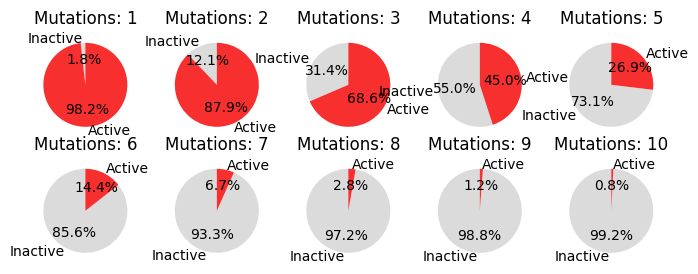

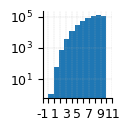

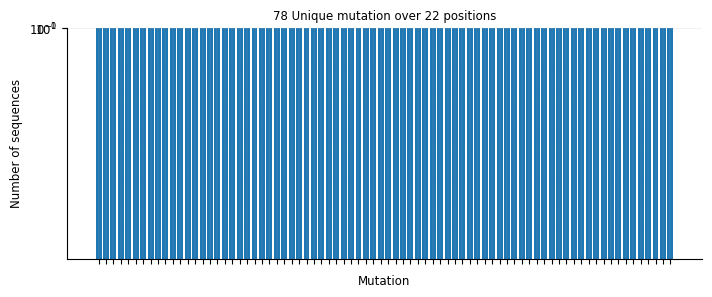

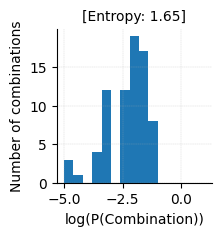

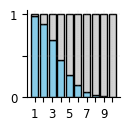

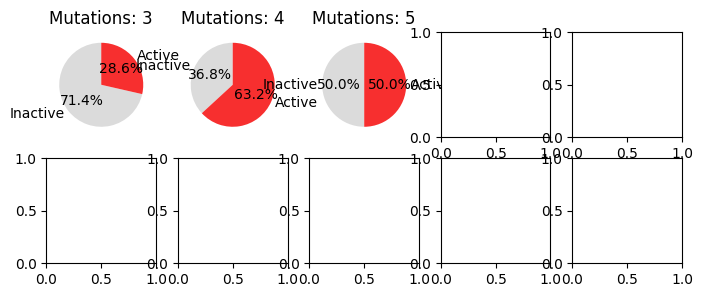

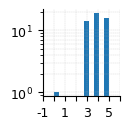

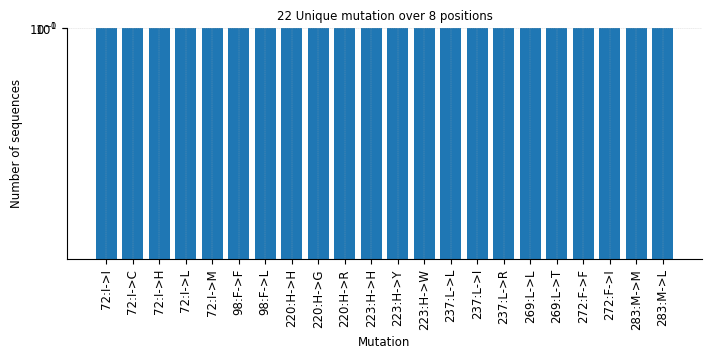

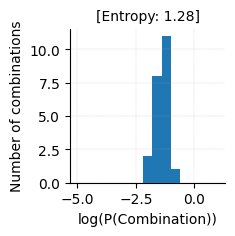

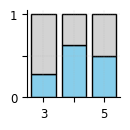

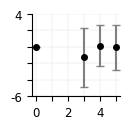

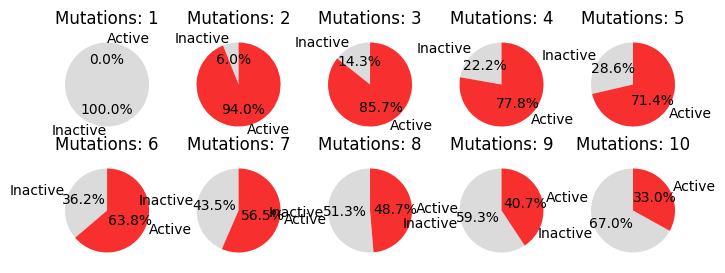

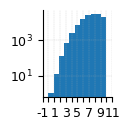

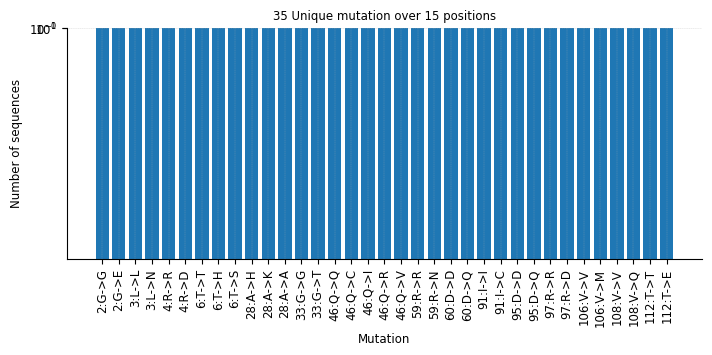

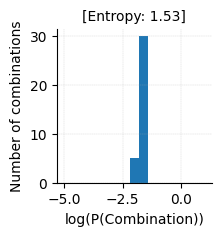

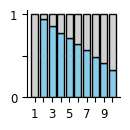

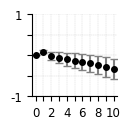

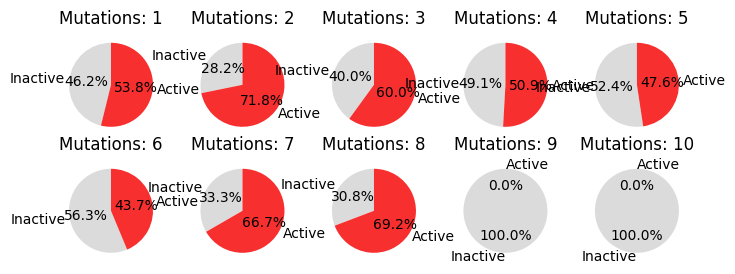

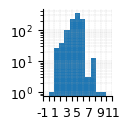

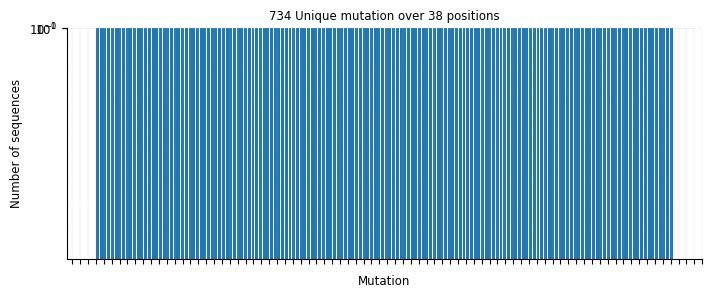

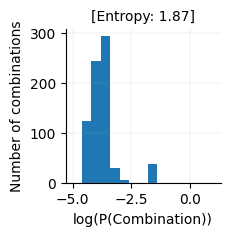

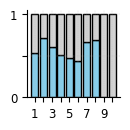

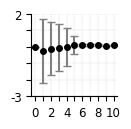

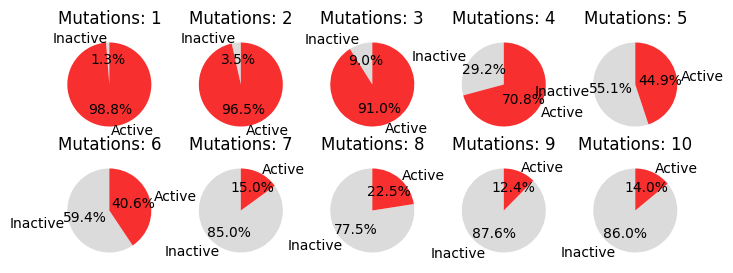

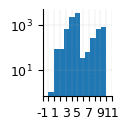

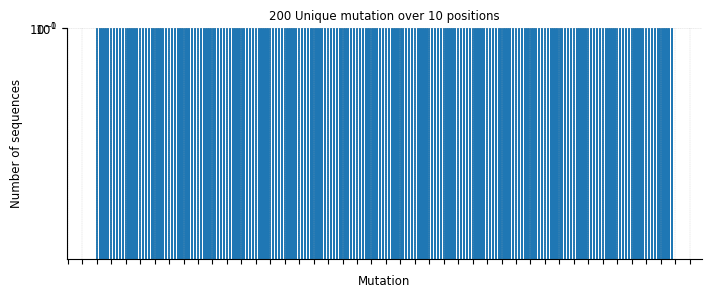

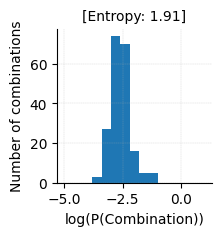

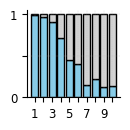

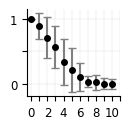

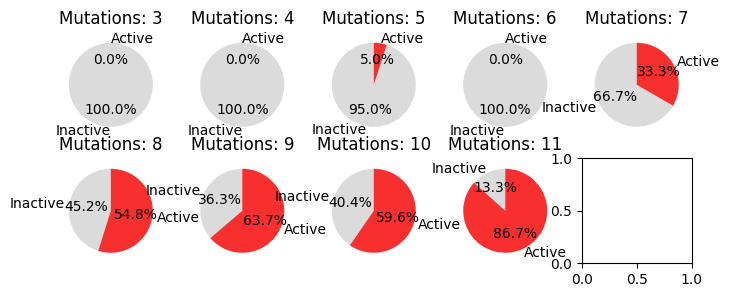

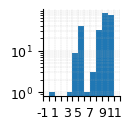

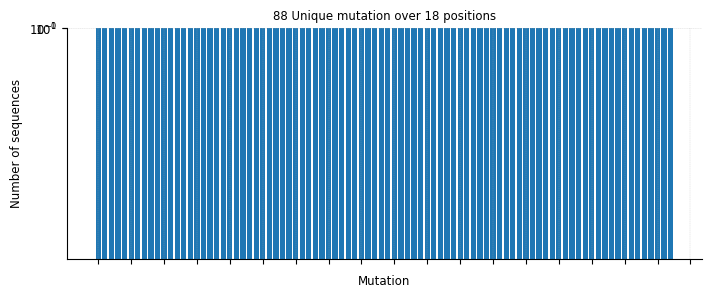

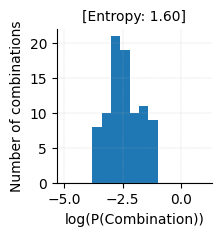

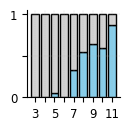

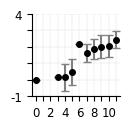

In [16]:
figures_path = "%s/refined_figures" % base_path
os.makedirs(figures_path, exist_ok=True)
os.makedirs(figures_path + "/figure_intro", exist_ok=True)

datasets_in_study =  ["gfp", "pte", "lov", "gcn4", "pard3", "nmt"]
activity_type_in_study =  ["discrete", "continuous", "continuous", "continuous", "continuous", "continuous"]

def make_pie_chart(probabilities_by_mutations, labels_title, tick_fontsize, plot_metadata):
    if "figsize" in plot_metadata:
        figsize = plot_metadata["figsize"]
    else:
        figsize = (8.2, 3)
    fig, axs = plt.subplots(2, 5, figsize=figsize)
    axs = axs.flatten()
    for i in range(len(probabilities_by_mutations)):
        axs[i].pie(np.stack(probabilities_by_mutations, axis=0)[i, 1:], 
                labels=labels_title, 
                autopct='%1.1f%%', 
                startangle=90,   
                colors=["#dbdbdb", "#f72f2f"])
        axs[i].set_title("Mutations: %d" % (probabilities_by_mutations[i][0]))
        axs[i].tick_params(axis='x', labelsize=tick_fontsize)
        axs[i].tick_params(axis='y', labelsize=tick_fontsize)
    for i in range(10, len(axs)):
        fig.delaxes(axs[i])
    if "tight_layout" in plot_metadata:
        plt.tight_layout()
    return fig

def make_mutation_number_hist(df, label_fontsize, tick_fontsize, plot_metadata):
    if "figsize" in plot_metadata:
        figsize = plot_metadata["figsize"]
    else:
        figsize = (1.4, 1.4)
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.hist(df["num_muts"], bins=11, density=False)
    #ax.set_xlabel("Number of mutations", fontsize=9)
    #ax.set_ylabel("Sequences (density)", fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_yscale("log")

    ax.xaxis.set_major_locator(MultipleLocator(1))
    fix_ticks(ax, x=True, y=False, every_other=True, fontsize=9)

    if "tight_layout" in plot_metadata:
        plt.tight_layout()
    return fig

def make_mutation_identity_hist(one_hot, all_muts_flat, label_fontsize, tick_fontsize, title_fontsize, plot_metadata):
    if "figsize" in plot_metadata:
        figsize = plot_metadata["figsize"]
    else:
        figsize = (8.2, 3)
    fig, ax = plt.subplots(figsize=figsize)

    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)    

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.bar(x=range(one_hot.shape[1]), height=one_hot.sum(axis=0))
    ax.set_ylim(0, 1)
    ax.set_xticks(range(one_hot.shape[1]))

    if "xtickslabels" in plot_metadata:
        if plot_metadata["xtickslabels"] is None:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(all_muts_flat, rotation=90, fontsize=8.5)
    else:
        ax.set_xticklabels(all_muts_flat, rotation=90, fontsize=8.5)

    ax.tick_params(axis='y', labelsize=8.5)
    ax.tick_params(axis='x', labelsize=8.5)
    ax.set_xlabel("Mutation", fontsize=8.5)
    ax.set_ylabel("Number of sequences", fontsize=8.5)
    if len(all_muts_flat) > 0:        
        n_positions = len(np.unique([a.split(":")[0] for a in all_muts_flat]))
    else:
        n_positions = 0
    ax.set_title("%d Unique mutation over %d positions" % (len(all_muts_flat), n_positions), fontsize=8.5)
    if "tight_layout" in plot_metadata:
        plt.tight_layout()

    ax.set_yscale("log")

    if "x_grid_bin" in plot_metadata:
        ax.xaxis.set_major_locator(MultipleLocator(plot_metadata["x_grid_bin"]))
        
    return fig

def make_logprob_dist_hist(one_hot, label_fontsize, tick_fontsize, entropy, plot_metadata):
    if "figsize" in plot_metadata:
        figsize = plot_metadata["figsize"]
    else:
        figsize = (2, 2)
    custom_bins = np.linspace(-5, 1, 16)
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.hist(np.log10(one_hot.sum(axis=0) / one_hot.sum()), bins=custom_bins)
    ax.set_xlabel("log(P(Combination))", fontsize=label_fontsize)
    ax.set_ylabel("Number of combinations", fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.set_title("[Entropy: %.2f]" % entropy, fontsize=label_fontsize)
    if "tight_layout" in plot_metadata:
        plt.tight_layout()
    return fig

def make_fraction_explained_barplot(prob_stack, tick_fontsize, plot_metadata):
    x = prob_stack[0:10,0]
    active = prob_stack[0:10,2]
    inactive = prob_stack[0:10,1]
    if "figsize" in plot_metadata:
        figsize = plot_metadata["figsize"]
    else:
        figsize = (1.4, 1.4)
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.bar(x, active, color="skyblue", edgecolor="k", label='Explained')
    ax.bar(x, inactive, bottom=active, color="lightgray", edgecolor="k", label='Unexplained')
    ax.set_xticks(x)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=8.5)
    ax.tick_params(axis='y', labelsize=8.5)
    fix_ticks(ax, x=False, y=True, every_other=False, ylim=[0, 1], ybreaks=3, fontsize=8.5)
    fix_ticks(ax, x=True, y=False, every_other=True, fontsize=8.5)
    if "tight_layout" in plot_metadata:
        plt.tight_layout()
    return fig

def make_activity_mean_sd_errorbar(n_muts, means, stds, plot_metadata):

    if "figsize" in plot_metadata:
        figsize = plot_metadata["figsize"]
    else:
        figsize = (1.4, 1.4)

    fig, ax = plt.subplots(figsize=figsize)

    ax.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.errorbar(n_muts, means, yerr=stds, fmt='o', color='black', ecolor='gray', capsize=3, markersize=4)

    xlim = plot_metadata["xlim"] if "xlim" in plot_metadata else None
    ylim = plot_metadata["ylim"] if "ylim" in plot_metadata else None
    
    fix_ticks(ax, x=False, y=True, every_other=False, fontsize=8.5, ylim=ylim)
    fix_ticks(ax, x=True, y=False, every_other=True, fontsize=8.5, xlim=xlim)
    ax.set_xlabel("")#("Number of mutations", fontsize=label_fontsize)
    ax.set_ylabel("")#("Activity", fontsize=label_fontsize)

    if "y_grid_bin" in plot_metadata:
        ax.yaxis.set_major_locator(MultipleLocator(plot_metadata["y_grid_bin"]))

    if "tight_layout" in plot_metadata:
        plt.tight_layout()

    return fig

metadata = {
    "gfp": {
        "pie_chart": {},
        "mutation_number_hist":  {"tight_layout": True},
        "mutation_identity_hist": {"xtickslabels": None},
        "logprob_dist_hist": {},
        "fraction_explained_barplot": {"tight_layout": True},
        "activity_mean_sd_errorbar": {"tight_layout": True, }
    },
    "pte": {
        "pie_chart": {},
        "mutation_number_hist": {"tight_layout": True},
        "mutation_identity_hist": {},
        "logprob_dist_hist": {},
        "fraction_explained_barplot": {"xlim": [0, 5], "tight_layout": True},
        "activity_mean_sd_errorbar": {"tight_layout": True, "xlim": [0, 5], "y_grid_bin": 2}
    },
    "lov": {
        "pie_chart": {},
        "mutation_number_hist": {"tight_layout": True},
        "mutation_identity_hist": {},
        "logprob_dist_hist": {},
        "fraction_explained_barplot": {"xlim": [0, 10], "tight_layout": True},
        "activity_mean_sd_errorbar": {"tight_layout": True, "xlim": [0, 10], "y_grid_bin": 0.5}
    },
    "gcn4": {
        "pie_chart": {},
        "mutation_number_hist": {"tight_layout": True},
        "mutation_identity_hist": {"xtickslabels": None, "x_grid_bin": 10},
        "logprob_dist_hist": {},
        "fraction_explained_barplot": {"xlim": [0, 10], "tight_layout": True},
        "activity_mean_sd_errorbar": {"tight_layout": True, "xlim": [0, 10]}     

    },
    "pard3": {
        "pie_chart": {},
        "mutation_number_hist": {"tight_layout": True},
        "mutation_identity_hist": {"xtickslabels": None, "x_grid_bin": 5},
        "logprob_dist_hist": {},
        "fraction_explained_barplot": {"xlim": [0, 11], "tight_layout": True},
        "activity_mean_sd_errorbar": {"tight_layout": True, "xlim": [0, 11], "y_grid_bin": 0.5, "ylim": [0, 1]}
    },
    "nmt": {
        "pie_chart": {},
        "mutation_number_hist": {"tight_layout": True},
        "mutation_identity_hist": {"xtickslabels": None, "x_grid_bin": 5},
        "logprob_dist_hist": {},
        "fraction_explained_barplot": {"xlim": [0, 11], "tight_layout": True},
        "activity_mean_sd_errorbar": {"tight_layout": True, "xlim": [0, 11]}
    }
}

for activity_type, working_dataset in zip(activity_type_in_study, datasets_in_study):
    df = pd.read_csv(DATASET_PATHS[working_dataset])
    discrete_labels = get_labels(working_dataset, discrete=True)

    if activity_type == "continuous":
        continuous_labels = get_labels(working_dataset, discrete=False)
    else:
        continuous_labels = None

    probabilities_by_mutations = []
    numt_muts_column = num_muts_column_name[working_dataset]

    n_muts = np.unique(df[numt_muts_column].to_numpy())
    n_muts = n_muts[n_muts > 0]
    for i in n_muts:
        counts = np.unique(discrete_labels[df[numt_muts_column] == i], return_counts=True)
        row = np.array([
            np.array([i]).astype(float)[0].item(),
            counts[1][0] / sum(counts[1]), 
            1 - counts[1][0] / sum(counts[1])
        ])
        probabilities_by_mutations.append(row)

    labels_title = ['Inactive', "Active"]
    sizes = np.stack(probabilities_by_mutations, axis=0)[-1, 1:]

    plot_metadata = metadata[working_dataset]["pie_chart"]
    pie_chart_fig = make_pie_chart(
        probabilities_by_mutations, 
        labels_title, 
        tick_fontsize,
        plot_metadata
    )
    pie_chart_fig.savefig("%s/figure_intro/pie_chart.svg" % figures_path, dpi=300)

    plot_metadata = metadata[working_dataset]["mutation_number_hist"]
    mutation_number_hist_fig = make_mutation_number_hist(
        df, 
        label_fontsize, 
        tick_fontsize,
        plot_metadata
    )

    one_hot = get_one_hot_encoding(df, positions[working_dataset][0], positions[working_dataset][1]).numpy()
    ei = np.where(df.columns == positions[working_dataset][1])[0][0]
    si = np.where(df.columns == positions[working_dataset][0])[0][0]
    all_muts = [["%d:%s->%s" % (int(C[1:]), C[0] ,mut) for mut in pd.unique(df[C]).tolist()] for C in df.columns[si:(ei+1)]]
    all_muts_flat = []

    for m in all_muts:
        all_muts_flat.extend(m)

    plot_metadata = metadata[working_dataset]["mutation_identity_hist"]
    mutation_identity_hist_fig = make_mutation_identity_hist(
        one_hot, 
        all_muts_flat, 
        label_fontsize, 
        tick_fontsize, 
        title_fontsize,
        plot_metadata
    )

    muts_prob_dist = one_hot.sum(axis=0) / one_hot.sum()
    entropy = np.sum(-np.log10(muts_prob_dist) * muts_prob_dist)

    plot_metadata = metadata[working_dataset]["logprob_dist_hist"]
    logprob_dist_hist_fig = make_logprob_dist_hist(
        one_hot, 
        label_fontsize, 
        tick_fontsize, 
        entropy,
        plot_metadata
    )
    
    prob_stack = np.stack(probabilities_by_mutations, axis=0)

    plot_metadata = metadata[working_dataset]["fraction_explained_barplot"]
    fraction_explained_barplot_fig = make_fraction_explained_barplot(
        prob_stack, 
        tick_fontsize,
        plot_metadata
    )




    activity_mean_sd_errorbar_fig = None

    if activity_type == "continuous":
        means = []
        stds = []
        n_muts_full = np.unique(df[numt_muts_column].to_numpy())
        for nm in n_muts_full:
            if working_dataset == "pard3":
                values = (continuous_labels[df["num_muts"] == nm] + 1e-10)
            else:
                values = np.log10(continuous_labels[df["num_muts"] == nm] + 1e-10)
            if len(values) > 0:
                means.append(np.mean(values))
                stds.append(np.std(values))
            else:
                means.append(np.nan)
                stds.append(np.nan)

        plot_metadata = metadata[working_dataset]["activity_mean_sd_errorbar"]
        print(plot_metadata)
        activity_mean_sd_errorbar_fig = make_activity_mean_sd_errorbar(
            n_muts_full, 
            means, 
            stds,
            plot_metadata
        )

    pie_chart_fig.savefig("%s/figure_intro/%s_pie_chart.svg" % (figures_path, working_dataset), dpi=300)
    mutation_number_hist_fig.savefig("%s/figure_intro/%s_mutation_number_hist.svg" % (figures_path, working_dataset), dpi=300)
    mutation_identity_hist_fig.savefig("%s/figure_intro/%s_mutation_identity_hist.svg" % (figures_path, working_dataset), dpi=300)
    logprob_dist_hist_fig.savefig("%s/figure_intro/%s_logprob_dist_hist.svg" % (figures_path, working_dataset), dpi=300)
    fraction_explained_barplot_fig.savefig("%s/figure_intro/%s_fraction_explained_barplot.svg" % (figures_path, working_dataset), dpi=300)
    if activity_mean_sd_errorbar_fig is not None:
        activity_mean_sd_errorbar_fig.savefig("%s/figure_intro/%s_activity_mean_sd_errorbar.svg" % (figures_path, working_dataset), dpi=300)


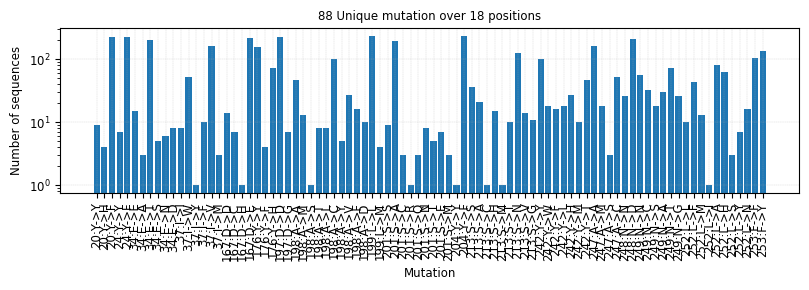

In [ ]:
if "figsize" in plot_metadata:
    figsize = plot_metadata["figsize"]
else:
    figsize = (8.2, 3)
plt.figure(figsize=figsize)

plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)

plt.bar(x=range(one_hot.shape[1]), height=one_hot.sum(axis=0))
plt.xticks(range(one_hot.shape[1]))

if "xtickslabels" in plot_metadata:
    if plot_metadata["xtickslabels"] is None:
        plt.gca().set_xticklabels([])
    else:
        plt.gca().set_xticklabels(all_muts_flat, rotation=90, fontsize=8.5)
else:
    plt.gca().set_xticklabels(all_muts_flat, rotation=90, fontsize=8.5)

plt.gca().tick_params(axis='y', labelsize=8.5)
plt.gca().tick_params(axis='x', labelsize=8.5)

# plt.xlabel("Mutation", fontsize=8.5)
# plt.ylabel("Number of sequences", fontsize=8.5)
# if len(all_muts_flat) > 0:        
#     n_positions = len(np.unique([a.split(":")[0] for a in all_muts_flat]))
# else:
#     n_positions = 0
# plt.title("%d Unique mutation over %d positions" % (len(all_muts_flat), n_positions), fontsize=8.5)
# if "tight_layout" in plot_metadata:
#     plt.tight_layout()

plt.yscale("log")

# if "x_grid_bin" in plot_metadata:
#     plt.gca().xaxis.set_major_locator(MultipleLocator(plot_metadata["x_grid_bin"]))

plt.savefig("%s/figure_intro/TMPTMP.svg" % (figures_path), dpi=300)



In [9]:
df = pd.read_csv(DATASET_PATHS["nmt"])
df

,name,seq,activity,num_muts,p1,p2,Y20,Y24,E34,I37,...,L199,S201,Y204,S213,Y242,A247,N248,N249,L252,F253
0,Wild type,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQILKHLLKNLF...,1.0,0,55.1,44.9,Y,Y,E,I,...,L,S,Y,S,Y,A,N,N,L,F
1,FL1_01,MESGFTSKDTYLSHFNPRDHLEKYYKFGSRHSAESQILKHLLKNLF...,0.1,5,NaN,NaN,H,Y,E,I,...,L,A,Y,A,Y,A,N,N,L,F
2,FL1_02,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQILKHLLKNLF...,21.2,5,60.6,39.4,Y,Y,E,I,...,L,C,Y,A,Y,A,N,C,L,F
3,FL1_03,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQILKHLLKNLF...,5.0,5,31.9,68.1,Y,Y,E,I,...,L,R,Y,S,W,A,N,S,L,F
4,FL1_04,MESGFTSKDTYLSHFNPRDFLEKYYKFGSRHSAESQILKHLLKNLF...,3.7,5,35.7,64.3,F,Y,E,I,...,L,C,Y,C,Y,A,N,N,L,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,FL3_H157,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQWLKHLLKNLF...,335.9,11,79.8,20.2,Y,Y,E,W,...,L,C,Y,C,H,C,N,A,M,Y
234,FL3_H158,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQWLKHLLKNLF...,384.7,10,8.1,91.9,Y,Y,E,W,...,L,C,Y,T,M,A,N,A,H,Y
235,FL3_H159,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQWLKHLLKNLF...,147.6,6,62.1,37.9,Y,Y,E,W,...,L,C,Y,S,H,A,N,T,L,F
236,FL3_H161,MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAESQWLKHLLKNLF...,1196.9,10,43.6,56.4,Y,Y,E,W,...,L,C,Y,V,F,A,N,A,Y,Y


In [48]:
wt = df["seq"][df["name"] == "Wild type"][0][0:34]
print("%s\n" %wt)

print(df["Y20"][np.where(df["Y20"] != "Y")[0][0]])
print(df["seq"][np.where(df["Y20"] != "Y")[0][0]][0:34])
tmp = list(wt)  # Strings are immutable, so just use list(wt). No need to copy.
tmp[19] = "H"
tmp = "".join(tmp)
print("%s\n" %tmp)

print(df["Y24"][np.where(df["Y24"] != "Y")[0][0]])
print(df["seq"][np.where(df["Y24"] != "Y")[0][0]][0:34])
tmp = list(wt)
tmp[23] = "F"
tmp = "".join(tmp)
print("%s\n" %tmp)

print(df["E34"][np.where(df["E34"] != "E")[0][0]])
print(df["seq"][np.where(df["E34"] != "E")[0][0]][0:34])
tmp = list(wt)
tmp[33] = "A"
tmp = "".join(tmp)
print("%s\n" %tmp)

# print(df["I37"][np.where(df["I37"] != "I")[0][0]])
# print(df["seq"][np.where(df["I37"] != "I")[0][0]][0:34])
# tmp = list("MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAE")
# tmp[19] = "H"
# tmp = "".join(tmp)
# print("%s\n" %tmp)





MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAE

H
MESGFTSKDTYLSHFNPRDHLEKYYKFGSRHSAE
MESGFTSKDTYLSHFNPRDHLEKYYKFGSRHSAE

F
MESGFTSKDTYLSHFNPRDYLEKFYKFGSRHSAE
MESGFTSKDTYLSHFNPRDYLEKFYKFGSRHSAE

A
MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAA
MESGFTSKDTYLSHFNPRDYLEKYYKFGSRHSAA



In [73]:

prot_gym_df = pd.read_csv("Protgym_datasets.csv")

with open("ProtGymMulti_muts.pkl", "rb") as f:
    muts_pkl = pkl.load(f)
    

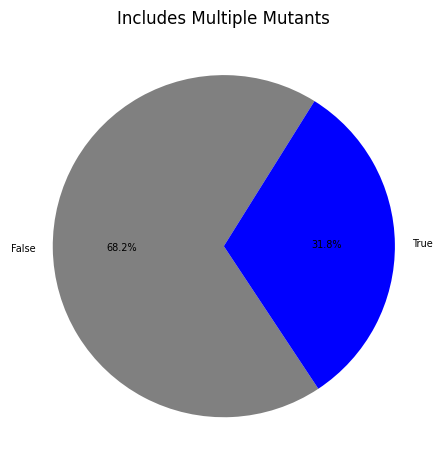

In [74]:
import matplotlib.pyplot as plt

counts = prot_gym_df["includes_multiple_mutants"].value_counts().sort_index()
labels = ['False', 'True']
if counts.index[0] == False:
    sizes = [counts[False], counts[True]]
else:
    sizes = [counts[True], counts[False]]

colors = ['gray', 'blue']

fig, ax = plt.subplots()
ax.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    textprops={'fontsize': 7},
    startangle=58 # Rotate 45 degrees up
)
ax.set_title('Includes Multiple Mutants')
plt.tight_layout()
plt.savefig("%s/figure_intro/protgym_includes_multiple_mutants.svg" % figures_path, dpi=300)
plt.show()

In [75]:

protgym_datasets_used = [
    "F7YBW8_MESOW_Ding_2023.csv", 
    "GCN4_YEAST_Staller_2018.csv",
    "PHOT_CHLRE_Chen_2023.csv"
]


prot_gym_used_mutations = []
prot_gym_not_used_mutations = []
new_datasets_mutations = []


for k, v in muts_pkl.items():
    prob_1_to_10_muts = np.zeros(10)
    counts = np.unique(v, return_counts=True)

    values_below_10 = counts[1][counts[0] <= 10]
    counts_below_10 = counts[0][counts[0] <= 10]

    prob_1_to_10_muts[counts_below_10 - 1] = values_below_10 / sum(values_below_10)

    if k in protgym_datasets_used:
        print(k)
        prot_gym_used_mutations.append(prob_1_to_10_muts)
    else:
        prot_gym_not_used_mutations.append(prob_1_to_10_muts)


for working_dataset in ["pte", "gfp", "nmt"]:
    df = pd.read_csv(DATASET_PATHS[working_dataset])
    numt_muts_column = num_muts_column_name[working_dataset]
    nmuts = df[numt_muts_column].to_numpy()
    prob_1_to_10_muts = np.zeros(10)
    counts = np.unique(nmuts, return_counts=True)

    values_below_10 = counts[1][counts[0] <= 10]
    counts_below_10 = counts[0][counts[0] <= 10]

    prob_1_to_10_muts[counts_below_10 - 1] = values_below_10 / sum(values_below_10)

    new_datasets_mutations.append(prob_1_to_10_muts)

        

F7YBW8_MESOW_Ding_2023.csv
GCN4_YEAST_Staller_2018.csv
PHOT_CHLRE_Chen_2023.csv


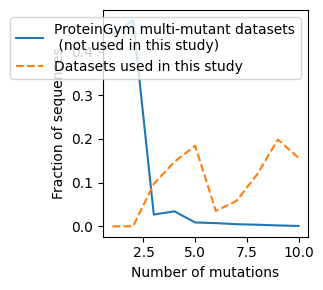

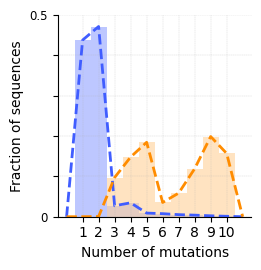

In [ ]:

our_datasets = np.concatenate([prot_gym_used_mutations, new_datasets_mutations], axis=0)

protein_gym_dist = np.array(prot_gym_not_used_mutations).mean(axis=0)
our_datasets_dist = np.array(new_datasets_mutations).mean(axis=0)

# Line plot version
plt.figure(figsize=(3, 3))
plt.plot(np.arange(1,11), protein_gym_dist, label="ProteinGym multi-mutant datasets\n (not used in this study)")
plt.plot(np.arange(1,11), our_datasets_dist, linestyle="--", label="Datasets used in this study")
plt.xlabel("Number of mutations")
plt.ylabel("Fraction of sequences")
plt.legend()
plt.tight_layout()
plt.savefig(f"{figures_path}/figure_intro/mutational_dist_regular.svg", dpi=300)
plt.show()

# Bar plot version

x = np.arange(1, 11)
plt.figure(figsize=(2.75,2.75))
plt.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Set bar_width so that bars fully touch (side-by-side, no gap): each bar occupies exactly half the bin
bar_width = 1 

plt.bar(
        x - bar_width/2 + 0.5,
        protein_gym_dist, 
        width=bar_width, 
        label="ProteinGym multi-mutant datasets\n (not used in this study)", 
        alpha=0.6, 
        align='center',
        color="#91a2ff" 
)
plt.bar(
        x + bar_width/2 - 0.5, 
        our_datasets_dist, 
        width=bar_width, 
        label="Datasets used in this study", 
        alpha=0.6, 
        align='center',
        color="#ffd199"
)

plt.plot(
        np.arange(0,12), 
        np.concatenate([np.array([0]), protein_gym_dist, np.array([0])]), 
        linestyle="--", 
        linewidth=2, 
        color="#405dff"
)
plt.plot(
        np.arange(0,12), 
        np.concatenate([np.array([0]), our_datasets_dist, np.array([0])]), 
        linestyle="--", 
        linewidth=2, 
        color="#ff8c00"
)

plt.xlabel("Number of mutations")
plt.ylabel("Fraction of sequences")
plt.xticks(x, x)
#plt.legend()
plt.tight_layout()
fix_ticks(ax, x=False, y=True, every_other=False) 
plt.savefig(f"{figures_path}/figure_intro/mutational_dist_fancy.svg", dpi=300)
plt.show()



'%s/refined_figures'